# Movie Revenue Driver Analysis Using Causal Models
**Dataset:** TMDB Box Office (`train.csv`, 3,000 movies)  |  **Outcome:** `revenue` (analysed on the log scale)

| Part | Content |
|---|---|
| Part 1 (sections 1-10) | Data audit, cleaning, feature engineering, EDA |
| Part 2 (sections 11-21) | Causal question, DAG, backdoor adjustment, IPW, refutation tests, DoWhy cross-check |


## 1. Setup

In [ ]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import MultiLabelBinarizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Libraries loaded")

Libraries loaded


## 2. Load the data
Run the cell and choose `train.csv` when the upload button appears.

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()
    PATH = list(uploaded.keys())[0]
except ImportError:            # running outside Colab
    PATH = "train.csv"

# utf-8-sig removes the hidden BOM character that otherwise renames 'id' to '\ufeffid'
df = pd.read_csv(PATH, encoding="utf-8-sig")
print("Shape:", df.shape)
df.head(3)

Saving train.csv to train.csv
Shape: (3000, 23)


,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000


## 3. First audit: types and missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

In [ ]:
missing = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing[missing > 0].to_frame("missing_%")

,missing_%
belongs_to_collection,79.9
homepage,68.5
tagline,19.9
Keywords,9.2
production_companies,5.2
production_countries,1.8
spoken_languages,0.7
crew,0.5
cast,0.4
overview,0.3


**Reading:** `belongs_to_collection` and `homepage` are mostly empty. Their *absence* is informative (a movie with no collection is a standalone film), so we will turn them into flags instead of dropping them.

## 4. Data quality checks

In [ ]:
print("Duplicate ids       :", df["id"].duplicated().sum())
print("Budget == 0         :", (df["budget"] == 0).sum(), f"({(df['budget'] == 0).mean():.1%})")
print("Runtime == 0        :", (df["runtime"] == 0).sum())
print("Revenue < 1,000     :", (df["revenue"] < 1000).sum())
print("Status counts       :", df["status"].value_counts().to_dict())
df[["budget", "revenue", "runtime", "popularity"]].describe().round(1)

Duplicate ids       : 0
Budget == 0         : 812 (27.1%)
Runtime == 0        : 12
Revenue < 1,000     : 57
Status counts       : {'Released': 2996, 'Rumored': 4}


,budget,revenue,runtime,popularity
count,3000.0,3.000000e+03,2998.0,3000.0
mean,22531334.1,6.672585e+07,107.9,8.5
std,37026086.4,1.375323e+08,22.1,12.1
min,0.0,1.000000e+00,0.0,0.0
25%,0.0,2.379808e+06,94.0,4.0
50%,8000000.0,1.680707e+07,104.0,7.4
75%,29000000.0,6.891920e+07,118.0,10.9
max,380000000.0,1.519558e+09,338.0,294.3


**Decisions**
- `budget = 0` means *unknown*, not free. We set it to NaN and keep a `budget_missing` flag.
- `runtime = 0` is impossible, so we set it to NaN and fill it with the median.
- Revenue is extremely right-skewed, so we use `log1p(revenue)`.

## 5. Cleaning

In [ ]:
clean = df.copy()

# 5.1 Dates: the file uses 2-digit years (e.g. 2/20/15). Data ends in 2017,
# so any parsed year above 2017 was really 19xx.
clean["release_date"] = pd.to_datetime(clean["release_date"], format="%m/%d/%y", errors="coerce")
clean.loc[clean["release_date"].dt.year > 2017, "release_date"] -= pd.DateOffset(years=100)
print("Release-date range:", clean["release_date"].min().date(), "to", clean["release_date"].max().date())
print("Missing dates     :", clean["release_date"].isna().sum())

# 5.2 Budget and runtime
clean["budget_missing"] = (clean["budget"] == 0).astype(int)
clean["budget"] = clean["budget"].replace(0, np.nan)
clean["runtime"] = clean["runtime"].replace(0, np.nan)
clean["runtime"] = clean["runtime"].fillna(clean["runtime"].median())

# 5.3 Fill the single/few missing dates with the median date so the row is not lost
clean["release_date"] = clean["release_date"].fillna(clean["release_date"].median())

Release-date range: 1921-01-21 to 2017-07-20
Missing dates     : 0


## 6. Parse the JSON-like text columns
Columns such as `genres` and `cast` are stored as text that looks like a list of dictionaries. `ast.literal_eval` converts them safely.

In [ ]:
def parse(cell):
    """Return a list of dicts, or [] if the cell is empty or malformed."""
    if pd.isna(cell):
        return []
    try:
        return ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        return []

def names(cell, key="name", top=None):
    items = parse(cell)
    items = items[:top] if top else items
    return [d[key] for d in items if key in d]

for col in ["belongs_to_collection", "genres", "production_companies",
            "production_countries", "spoken_languages", "Keywords", "cast", "crew"]:
    clean[col + "_parsed"] = clean[col].apply(parse)

clean["genre_list"] = clean["genres"].apply(names)
print(clean["genre_list"].head(5).tolist())

[['Comedy'], ['Comedy', 'Drama', 'Family', 'Romance'], ['Drama'], ['Thriller', 'Drama'], ['Action', 'Thriller']]


## 7. Feature engineering

In [ ]:
# Counts and flags
clean["n_genres"]     = clean["genre_list"].apply(len)
clean["n_companies"]  = clean["production_companies_parsed"].apply(len)
clean["n_countries"]  = clean["production_countries_parsed"].apply(len)
clean["n_languages"]  = clean["spoken_languages_parsed"].apply(len)
clean["n_keywords"]   = clean["Keywords_parsed"].apply(len)
clean["cast_size"]    = clean["cast_parsed"].apply(len)
clean["crew_size"]    = clean["crew_parsed"].apply(len)

clean["in_collection"] = (clean["belongs_to_collection_parsed"].apply(len) > 0).astype(int)
clean["has_homepage"]  = clean["homepage"].notna().astype(int)
clean["has_tagline"]   = clean["tagline"].notna().astype(int)
clean["is_english"]    = (clean["original_language"] == "en").astype(int)
clean["is_us_made"]    = clean["production_countries_parsed"].apply(
    lambda lst: int(any(d.get("iso_3166_1") == "US" for d in lst)))

# Release timing
clean["release_year"]    = clean["release_date"].dt.year
clean["release_month"]   = clean["release_date"].dt.month
clean["release_quarter"] = clean["release_date"].dt.quarter
clean["release_dow"]     = clean["release_date"].dt.dayofweek
clean["is_summer"]       = clean["release_month"].isin([5, 6, 7]).astype(int)
clean["is_holiday_season"] = clean["release_month"].isin([11, 12]).astype(int)

# Log transforms
clean["log_revenue"] = np.log1p(clean["revenue"])
clean["log_budget"]  = np.log1p(clean["budget"])
clean["log_popularity"] = np.log1p(clean["popularity"])

# Director (first crew member whose job is Director)
def get_director(lst):
    for d in lst:
        if d.get("job") == "Director":
            return d.get("name")
    return None
clean["director"] = clean["crew_parsed"].apply(get_director)

# Multi-label genre dummies for the 12 most common genres
mlb = MultiLabelBinarizer()
g = pd.DataFrame(mlb.fit_transform(clean["genre_list"]), columns=mlb.classes_, index=clean.index)
top_genres = g.sum().sort_values(ascending=False).head(12).index.tolist()
g = g[top_genres].add_prefix("genre_")
clean = pd.concat([clean, g], axis=1)

print("Top genres:", top_genres)
print("New shape :", clean.shape)

Top genres: ['Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 'Crime', 'Adventure', 'Horror', 'Science Fiction', 'Family', 'Fantasy', 'Mystery']
New shape : (3000, 67)


## 8. Exploratory data analysis

### 8.1 Why we log-transform revenue

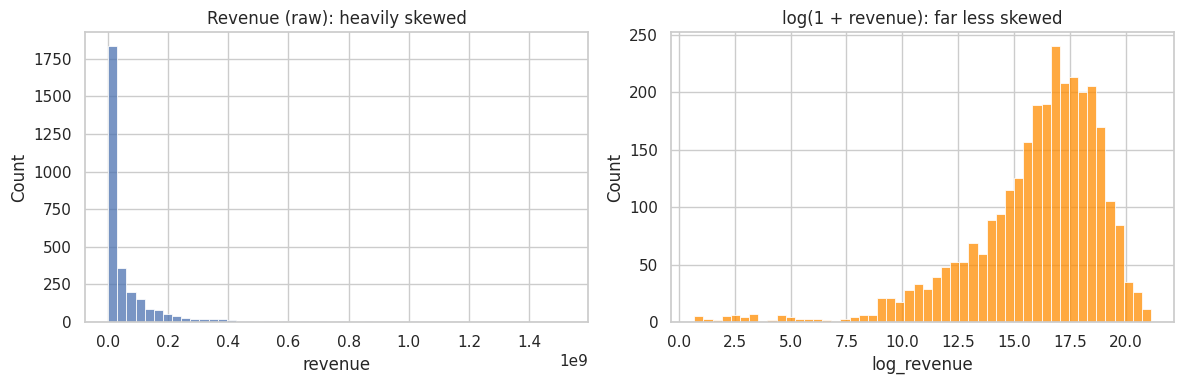

Skewness raw: 4.54 | log: -1.65


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clean["revenue"], bins=50, ax=ax[0]); ax[0].set_title("Revenue (raw): heavily skewed")
sns.histplot(clean["log_revenue"], bins=50, ax=ax[1], color="darkorange"); ax[1].set_title("log(1 + revenue): far less skewed")
plt.tight_layout(); plt.show()
print("Skewness raw:", round(clean["revenue"].skew(), 2), "| log:", round(clean["log_revenue"].skew(), 2))

**Note:** the log scale cuts skewness from 4.5 to about -1.6. The remaining left tail comes from 57 movies with revenue under $1,000, which are probably data-entry errors. Part 2 will test whether dropping them changes the conclusions.

### 8.2 Budget vs revenue

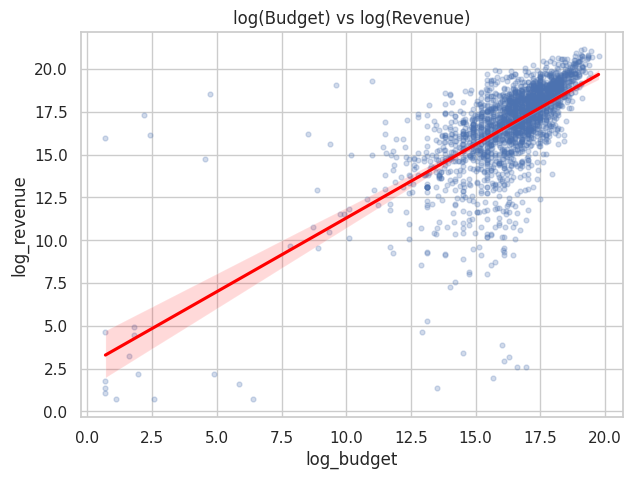

Correlation (log budget, log revenue): 0.659


In [ ]:
plt.figure(figsize=(7, 5))
sns.regplot(data=clean.dropna(subset=["log_budget"]), x="log_budget", y="log_revenue",
            scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"})
plt.title("log(Budget) vs log(Revenue)")
plt.show()

known = clean.dropna(subset=["budget"])
print("Correlation (log budget, log revenue):", round(known["log_budget"].corr(known["log_revenue"]), 3))

### 8.3 Genre

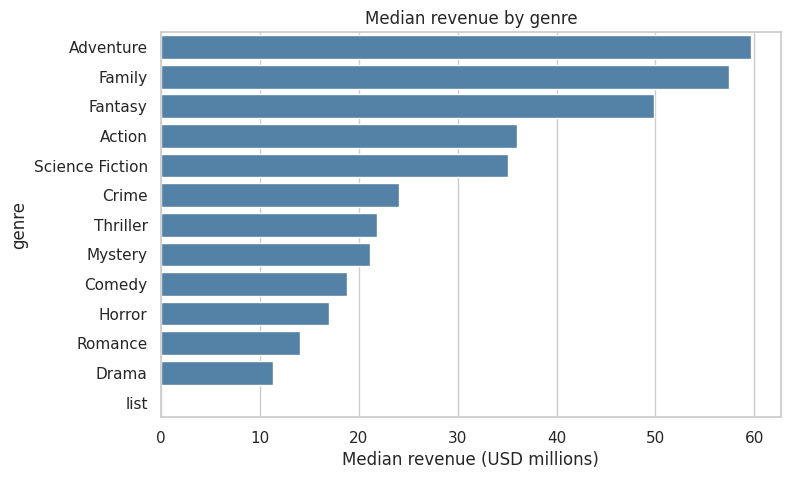

,genre,movies,median_revenue_M
7,Adventure,439,59.7
10,Family,260,57.5
11,Fantasy,232,49.8
4,Action,741,36.0
9,Science Fiction,290,35.1
6,Crime,469,24.0
3,Thriller,789,21.9
12,Mystery,225,21.1
2,Comedy,1028,18.8
8,Horror,301,17.0


In [ ]:
genre_cols = [c for c in clean.columns if c.startswith("genre_")]
rows = []
for c in genre_cols:
    sub = clean[clean[c] == 1]
    rows.append({"genre": c.replace("genre_", ""), "movies": len(sub), "median_revenue_M": sub["revenue"].median() / 1e6})
genre_stats = pd.DataFrame(rows).sort_values("median_revenue_M", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=genre_stats, y="genre", x="median_revenue_M", color="steelblue")
plt.xlabel("Median revenue (USD millions)"); plt.title("Median revenue by genre")
plt.show()
genre_stats.round(1)

### 8.4 Timing: month and year

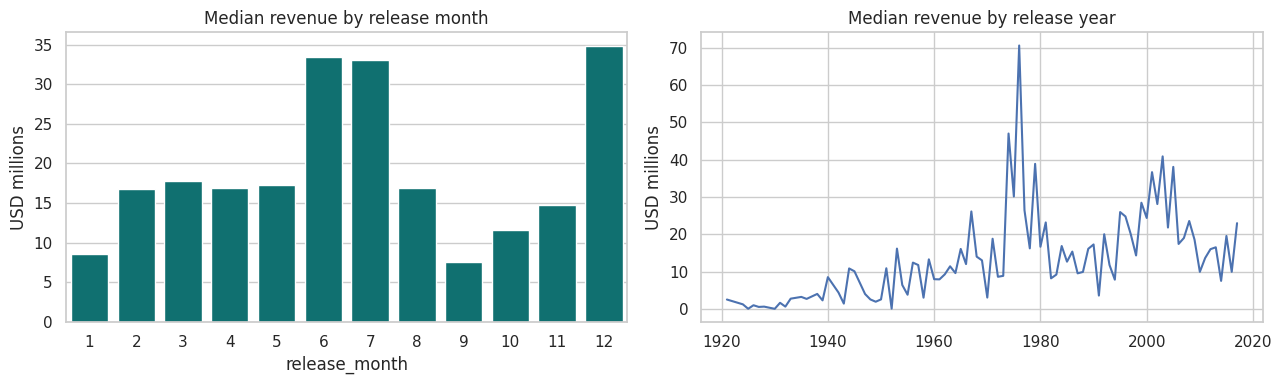

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
m = clean.groupby("release_month")["revenue"].median() / 1e6
sns.barplot(x=m.index, y=m.values, ax=ax[0], color="teal")
ax[0].set_title("Median revenue by release month"); ax[0].set_ylabel("USD millions")

y = clean.groupby("release_year")["revenue"].median() / 1e6
ax[1].plot(y.index, y.values); ax[1].set_title("Median revenue by release year"); ax[1].set_ylabel("USD millions")
plt.tight_layout(); plt.show()

### 8.5 Franchise, homepage and language

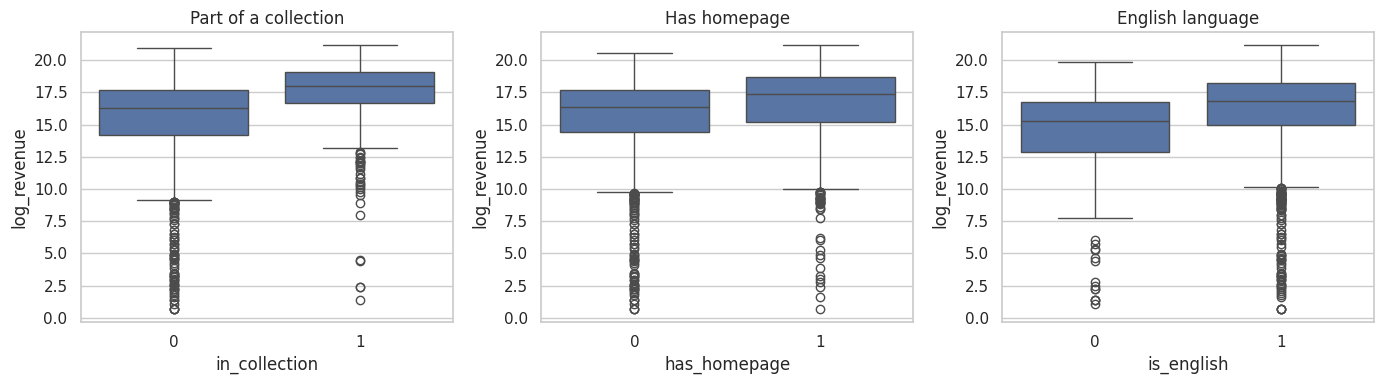

,median revenue (M)
in_collection,
0,11.4
1,67.4


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, col, title in zip(ax, ["in_collection", "has_homepage", "is_english"],
                         ["Part of a collection", "Has homepage", "English language"]):
    sns.boxplot(data=clean, x=col, y="log_revenue", ax=a)
    a.set_title(title)
plt.tight_layout(); plt.show()

clean.groupby("in_collection")["revenue"].median().div(1e6).round(1).rename("median revenue (M)")

### 8.6 Correlation with log revenue

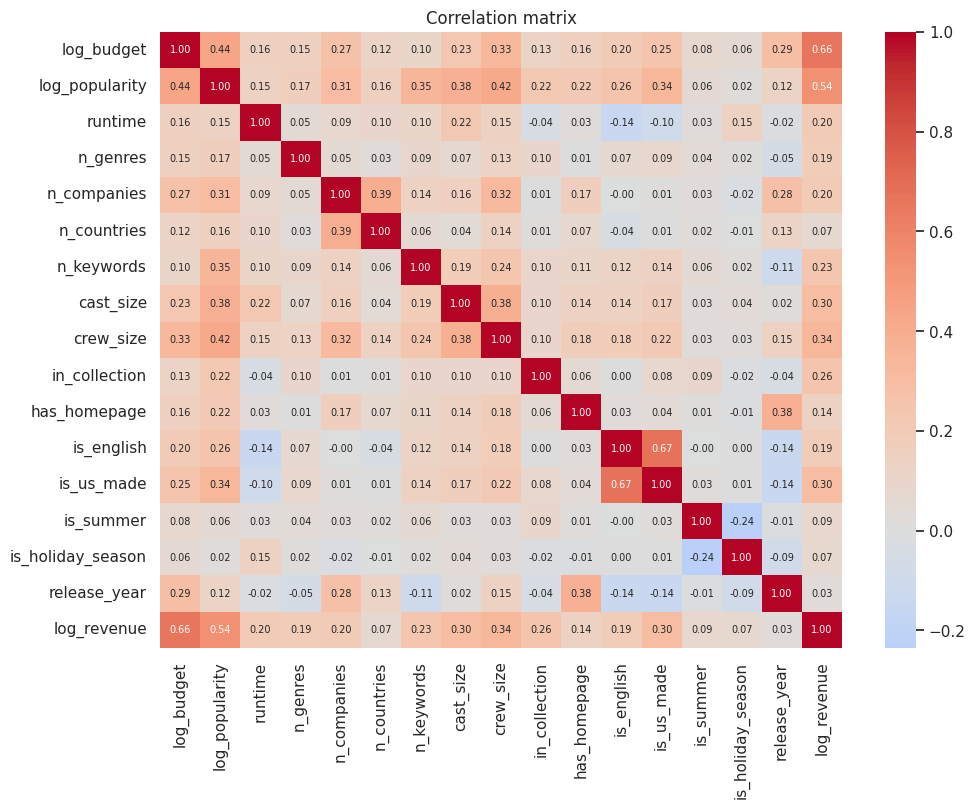

,log_revenue
log_budget,0.659
log_popularity,0.542
crew_size,0.341
cast_size,0.300
is_us_made,0.300
in_collection,0.257
n_keywords,0.235
runtime,0.203
n_companies,0.203
is_english,0.194


In [ ]:
num_cols = ["log_budget", "log_popularity", "runtime", "n_genres", "n_companies", "n_countries",
            "n_keywords", "cast_size", "crew_size", "in_collection", "has_homepage",
            "is_english", "is_us_made", "is_summer", "is_holiday_season", "release_year", "log_revenue"]
corr = clean[num_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation matrix"); plt.show()

corr["log_revenue"].drop("log_revenue").sort_values(ascending=False).round(3)

**Important note for the mentor:** these are *correlations*. `popularity` and `cast_size`, for example, may be consequences of a movie's success rather than causes, so they should not be used as adjustment variables in the causal step. Part 2 addresses this with a DAG.

## 9. Save the cleaned dataset

In [ ]:
drop_cols = [c for c in clean.columns if c.endswith("_parsed")] + ["genre_list"]
final = clean.drop(columns=drop_cols)
final.to_csv("clean_movies.csv", index=False)
print("Saved clean_movies.csv:", final.shape)

try:
    from google.colab import files
    files.download("clean_movies.csv")
except ImportError:
    pass

Saved clean_movies.csv: (3000, 58)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Part 1 checkpoint
- 3,000 movies; 27% of budgets were recorded as 0 and were treated as missing.
- Revenue is heavily right-skewed, so `log1p(revenue)` is used.
- Text columns were parsed into counts, flags, genre dummies and release-timing features.
- `clean_movies.csv` is saved and will be reused for Streamlit and Power BI.

EDA shows correlations only. Part 2 asks the causal question.

# PART 2: Causal Analysis

## 11. Causal questions and assumptions

**Q1.** How much does a higher **budget** change a movie's revenue?
**Q2.** How much does being part of a **franchise (collection)** change revenue?

**Why not just use the correlations above?** Big-budget movies also tend to be franchise films, recent, English-language, and in certain genres. Those factors also raise revenue, so the raw budget-revenue relationship mixes the budget effect with these other effects (**confounding**).

**Approach:** decide from domain logic which variables are *confounders* (cause both treatment and outcome), *mediators* (sit on the path treatment -> outcome) or *consequences* of revenue, and adjust only for the right ones (the **backdoor criterion**).

**Assumptions (must be stated to be honest about the limits):**
1. No unmeasured confounders beyond the ones in the DAG (e.g. star power, marketing spend and director reputation are not measured well here).
2. Budget and franchise status are determined *before* release.
3. Only movies with a known budget are used for Q1, so results apply to that group.

## 12. The causal graph (DAG)

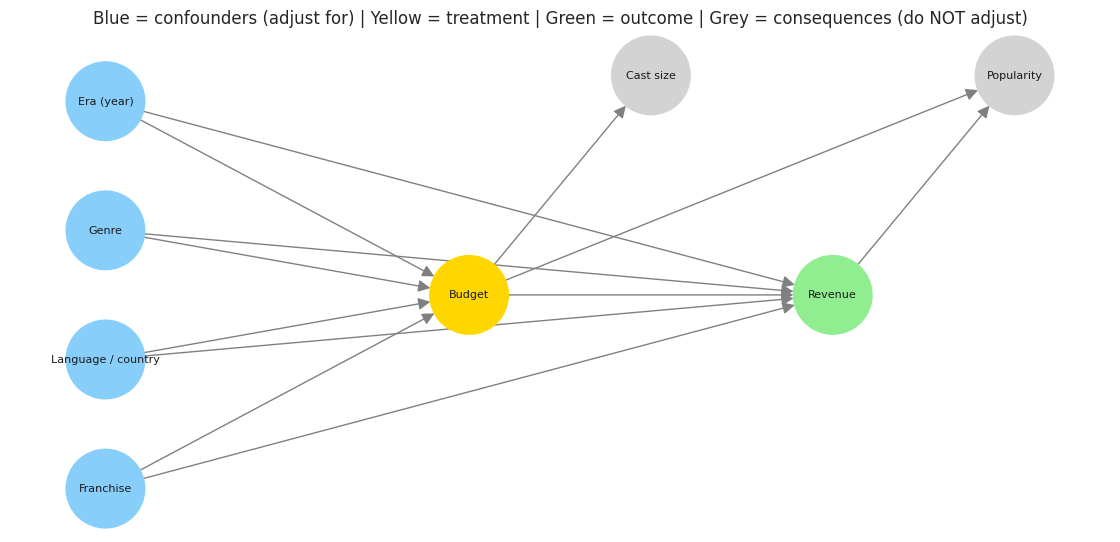

In [ ]:
G = nx.DiGraph()
edges = [
    ("Era (year)", "Budget"), ("Era (year)", "Revenue"),
    ("Genre", "Budget"), ("Genre", "Revenue"),
    ("Language / country", "Budget"), ("Language / country", "Revenue"),
    ("Franchise", "Budget"), ("Franchise", "Revenue"),
    ("Budget", "Revenue"),
    ("Budget", "Cast size"), ("Budget", "Popularity"), ("Revenue", "Popularity"),
]
G.add_edges_from(edges)

pos = {"Era (year)": (0, 3), "Genre": (0, 2), "Language / country": (0, 1), "Franchise": (0, 0),
       "Budget": (2, 1.5), "Revenue": (4, 1.5), "Cast size": (3, 3.2), "Popularity": (5, 3.2)}
colors = {"Budget": "gold", "Revenue": "lightgreen", "Cast size": "lightgray", "Popularity": "lightgray"}
node_colors = [colors.get(n, "lightskyblue") for n in G.nodes]

plt.figure(figsize=(11, 5))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=3200, font_size=8,
        arrows=True, arrowsize=18, edge_color="gray")
plt.title("Blue = confounders (adjust for) | Yellow = treatment | Green = outcome | Grey = consequences (do NOT adjust)")
plt.show()

**Reading the DAG**
- **Blue nodes** affect both budget and revenue, so we adjust for them.
- **Cast size and popularity** are *consequences* of budget (and popularity also of revenue). Adjusting for them would block part of the real budget effect or open a spurious path. We deliberately exclude them, and Section 14 shows what goes wrong if we include them.
- **Franchise** is decided before the budget is set, so for Q1 it is a confounder. For Q2 (effect of franchise), budget becomes a *mediator*: franchise -> bigger budget -> revenue.

## 13. Prepare the analysis samples

In [ ]:
if "final" not in globals():                      # allows running Part 2 on its own
    final = pd.read_csv("clean_movies.csv", parse_dates=["release_date"])

data = final.copy()
data["era"] = data["release_year"] - 2000
genre_cols = [c for c in data.columns if c.startswith("genre_")]
BASE_CONFOUNDERS = ["era", "is_english", "is_us_made"] + genre_cols

d_all = data[data["revenue"] >= 1000].copy()                 # drop implausible revenues
d_budget = d_all.dropna(subset=["log_budget"]).copy()        # budget known (Q1 sample)

print("All movies            :", len(data))
print("After revenue >= 1000 :", len(d_all))
print("Budget also known     :", len(d_budget))

All movies            : 3000
After revenue >= 1000 : 2943
Budget also known     : 2165


Helper functions: an OLS regression with heteroskedasticity-robust (HC1) standard errors, written with NumPy so every step is visible.

In [ ]:
def effect(df, y, treat, controls):
    """OLS of y on [treat + controls]; returns the treatment coefficient with a robust 95% CI."""
    cols = [treat] + controls
    X = np.column_stack([np.ones(len(df))] + [df[c].astype(float).values for c in cols])
    Y = df[y].astype(float).values
    n, k = X.shape
    XtX_inv = np.linalg.pinv(X.T @ X)
    beta = XtX_inv @ X.T @ Y
    resid = Y - X @ beta
    Xe = X * resid[:, None]
    cov = XtX_inv @ (Xe.T @ Xe) @ XtX_inv * n / (n - k)     # HC1 robust covariance
    se = np.sqrt(np.diag(cov))
    return {"coef": beta[1], "se": se[1], "ci_low": beta[1] - 1.96 * se[1],
            "ci_high": beta[1] + 1.96 * se[1], "n": n}

def show(results):
    return pd.DataFrame(results).T[["coef", "se", "ci_low", "ci_high", "n"]].round(3)

res = {}

## 14. Q1: effect of budget on revenue

In [ ]:
CONF_Q1 = BASE_CONFOUNDERS + ["in_collection"]

res["Naive (no adjustment)"] = effect(d_budget, "log_revenue", "log_budget", [])
res["Adjusted (backdoor set)"] = effect(d_budget, "log_revenue", "log_budget", CONF_Q1)
res["WRONG: + popularity, cast size"] = effect(d_budget, "log_revenue", "log_budget",
                                                CONF_Q1 + ["log_popularity", "cast_size"])
q1 = show({k: res[k] for k in list(res)})
q1

,coef,se,ci_low,ci_high,n
Naive (no adjustment),0.778,0.055,0.671,0.886,2165.0
Adjusted (backdoor set),0.703,0.067,0.572,0.834,2165.0
"WRONG: + popularity, cast size",0.559,0.059,0.443,0.675,2165.0


In [ ]:
b_naive = res["Naive (no adjustment)"]["coef"]
b_adj = res["Adjusted (backdoor set)"]["coef"]
pct_adj = (1.10 ** b_adj - 1) * 100
print(f"Naive coefficient    : {b_naive:.3f}")
print(f"Adjusted coefficient : {b_adj:.3f}  (elasticity)")
print(f"Interpretation       : a 10% higher budget is associated with about {pct_adj:.1f}% higher revenue,")
print("                       holding era, genre, language/country and franchise status fixed.")

Naive coefficient    : 0.778
Adjusted coefficient : 0.703  (elasticity)
Interpretation       : a 10% higher budget is associated with about 6.9% higher revenue,
                       holding era, genre, language/country and franchise status fixed.


**What to notice**
- Adjusting for confounders changes the estimate, which shows the naive number was contaminated.
- Adding popularity and cast size (bad controls) lowers the budget estimate noticeably (about 0.70 to 0.56), because they are *consequences of budget*. Controlling for them removes part of the real effect. This is a classic mistake that predictive models make silently.

## 15. Q2: effect of franchise status on revenue

For the **total** effect of being in a franchise we do *not* adjust for budget (it is a mediator). We then compare with the **direct** effect that holds budget fixed.

In [ ]:
res_q2 = {}
res_q2["Naive difference"] = effect(d_all, "log_revenue", "in_collection", [])
res_q2["Total effect (adjusted)"] = effect(d_all, "log_revenue", "in_collection", BASE_CONFOUNDERS)
res_q2["Direct effect (budget held fixed)"] = effect(d_budget, "log_revenue", "in_collection",
                                                      BASE_CONFOUNDERS + ["log_budget"])
q2 = show(res_q2)
q2["approx % change in revenue"] = ((np.exp(q2["coef"]) - 1) * 100).round(0)
q2

,coef,se,ci_low,ci_high,n,approx % change in revenue
Naive difference,1.814,0.101,1.616,2.012,2943.0,513.0
Total effect (adjusted),1.379,0.100,1.184,1.574,2943.0,297.0
Direct effect (budget held fixed),1.016,0.088,0.844,1.189,2165.0,176.0


### 15.1 Second method: inverse probability weighting (IPW)

IPW estimates the probability of being a franchise film from the confounders (the *propensity score*), then re-weights movies so franchise and non-franchise groups look alike. If the two methods agree, the result is more trustworthy.

In [ ]:
from sklearn.linear_model import LogisticRegression

def ipw_ate(df, treat, y, covs, clip=(0.02, 0.98)):
    X = df[covs].astype(float).values
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-9)
    t = df[treat].values
    ps = LogisticRegression(max_iter=1000).fit(Xs, t).predict_proba(Xs)[:, 1]
    ps = np.clip(ps, *clip)
    w = np.where(t == 1, 1 / ps, 1 / (1 - ps))
    yv = df[y].values
    ate = np.average(yv[t == 1], weights=w[t == 1]) - np.average(yv[t == 0], weights=w[t == 0])
    return ate, ps, w

ate, ps, w = ipw_ate(d_all, "in_collection", "log_revenue", BASE_CONFOUNDERS)

rng = np.random.default_rng(42)
boot = []
for _ in range(200):
    s = d_all.sample(frac=1.0, replace=True, random_state=int(rng.integers(1e9)))
    boot.append(ipw_ate(s, "in_collection", "log_revenue", BASE_CONFOUNDERS)[0])
lo, hi = np.percentile(boot, [2.5, 97.5])

res_q2["IPW (total effect)"] = {"coef": ate, "se": np.std(boot), "ci_low": lo, "ci_high": hi, "n": len(d_all)}
print(f"IPW estimate: {ate:.3f}  (95% bootstrap CI {lo:.3f} to {hi:.3f})")
print(f"Regression   : {res_q2['Total effect (adjusted)']['coef']:.3f}")

IPW estimate: 1.352  (95% bootstrap CI 1.033 to 1.673)
Regression   : 1.379


### 15.2 Did the weighting balance the groups? (standardised mean differences)

In [ ]:
def smd(x, t, wts=None):
    w1 = None if wts is None else wts[t == 1]
    w0 = None if wts is None else wts[t == 0]
    m1, m0 = np.average(x[t == 1], weights=w1), np.average(x[t == 0], weights=w0)
    sd = np.sqrt((x[t == 1].var() + x[t == 0].var()) / 2) + 1e-9
    return (m1 - m0) / sd

t = d_all["in_collection"].values
bal = pd.DataFrame({
    "before": [smd(d_all[c].astype(float).values, t) for c in BASE_CONFOUNDERS],
    "after_IPW": [smd(d_all[c].astype(float).values, t, w) for c in BASE_CONFOUNDERS],
}, index=BASE_CONFOUNDERS).abs().round(3)

print("Max |SMD| before:", bal["before"].max(), "| after:", bal["after_IPW"].max(), "(rule of thumb: below 0.1 is good)")
bal.sort_values("before", ascending=False).head(8)

Max |SMD| before: 0.813 | after: 0.114 (rule of thumb: below 0.1 is good)


,before,after_IPW
genre_Drama,0.813,0.000
genre_Adventure,0.489,0.031
genre_Romance,0.450,0.114
genre_Action,0.439,0.015
genre_Horror,0.399,0.001
genre_Science Fiction,0.304,0.042
genre_Family,0.291,0.035
genre_Fantasy,0.215,0.032


## 16. Refutation tests for the budget effect

A causal estimate should survive attempts to break it:
1. **Placebo treatment:** shuffle budget randomly. The effect should collapse to about 0.
2. **Random common cause:** add a random noise variable as a control. The estimate should not move.
3. **Data subset:** re-estimate on random 80% samples. The estimate should be stable.
4. **Data-quality sensitivity:** change the minimum-revenue filter and see how the estimate reacts.

In [ ]:
rng = np.random.default_rng(42)
base = effect(d_budget, "log_revenue", "log_budget", CONF_Q1)["coef"]

# 1. placebo
placebo = []
for _ in range(200):
    tmp = d_budget.copy()
    tmp["log_budget"] = rng.permutation(tmp["log_budget"].values)
    placebo.append(effect(tmp, "log_revenue", "log_budget", CONF_Q1)["coef"])

# 2. random common cause
rcc = []
for _ in range(200):
    tmp = d_budget.copy()
    tmp["noise"] = rng.normal(size=len(tmp))
    rcc.append(effect(tmp, "log_revenue", "log_budget", CONF_Q1 + ["noise"])["coef"])

# 3. subsets
sub = []
for _ in range(200):
    tmp = d_budget.sample(frac=0.8, random_state=int(rng.integers(1e9)))
    sub.append(effect(tmp, "log_revenue", "log_budget", CONF_Q1)["coef"])

ref = pd.DataFrame({
    "original estimate": [base] * 3,
    "refuted estimate (mean)": [np.mean(placebo), np.mean(rcc), np.mean(sub)],
    "spread (2.5%-97.5%)": [f"{np.percentile(a, 2.5):.3f} to {np.percentile(a, 97.5):.3f}" for a in (placebo, rcc, sub)],
    "expected": ["about 0", "unchanged", "unchanged"],
}, index=["Placebo treatment", "Random common cause", "80% subset"]).round(3)
ref

,original estimate,refuted estimate (mean),spread (2.5%-97.5%),expected
Placebo treatment,0.703,-0.001,-0.047 to 0.043,about 0
Random common cause,0.703,0.703,0.702 to 0.704,unchanged
80% subset,0.703,0.700,0.653 to 0.773,unchanged


In [ ]:
rows = {}
for thr in [1, 1000, 100000]:
    sub_df = data[(data["revenue"] >= thr)].dropna(subset=["log_budget"])
    r = effect(sub_df, "log_revenue", "log_budget", CONF_Q1)
    rows[f"revenue >= ${thr:,}"] = r
sens = show(rows)
sens

,coef,se,ci_low,ci_high,n
revenue >= $1,0.819,0.055,0.711,0.927,2188.0
"revenue >= $1,000",0.703,0.067,0.572,0.834,2165.0
"revenue >= $100,000",0.591,0.062,0.470,0.711,2099.0


**How to read this:** the placebo effect near 0 and the stable random-common-cause and subset results support the estimate's internal consistency. The data-quality table shows how much the estimate depends on the treatment of very small revenue values, so it should be reported as a range rather than a single number.

## 17. Does the budget effect differ across groups? (heterogeneity)

In [ ]:
het = {}
for name, cond in [("Franchise films", d_budget["in_collection"] == 1),
                   ("Non-franchise films", d_budget["in_collection"] == 0),
                   ("Released before 2000", d_budget["release_year"] < 2000),
                   ("Released 2000 or later", d_budget["release_year"] >= 2000)]:
    het[name] = effect(d_budget[cond], "log_revenue", "log_budget",
                       [c for c in CONF_Q1 if c != "in_collection"] if "ranchise" in name else CONF_Q1)
show(het)

,coef,se,ci_low,ci_high,n
Franchise films,0.653,0.134,0.390,0.916,497.0
Non-franchise films,0.720,0.075,0.573,0.867,1668.0
Released before 2000,0.541,0.096,0.353,0.729,773.0
Released 2000 or later,0.787,0.090,0.610,0.964,1392.0


## 18. Summary chart and export

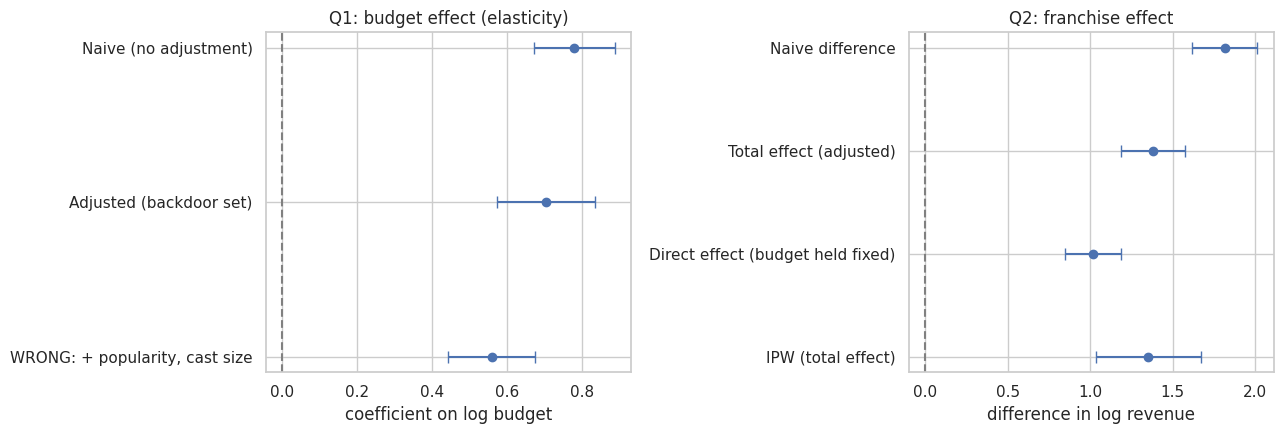

Saved causal_results.csv: (14, 7)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

def forest(a, results, title, xlabel):
    names = list(results.keys())
    coefs = [results[k]["coef"] for k in names]
    err = [[results[k]["coef"] - results[k]["ci_low"] for k in names],
           [results[k]["ci_high"] - results[k]["coef"] for k in names]]
    a.errorbar(coefs, range(len(names)), xerr=err, fmt="o", capsize=4)
    a.set_yticks(range(len(names))); a.set_yticklabels(names)
    a.axvline(0, color="gray", ls="--"); a.set_title(title); a.set_xlabel(xlabel)
    a.invert_yaxis()

forest(ax[0], {k: res[k] for k in ["Naive (no adjustment)", "Adjusted (backdoor set)", "WRONG: + popularity, cast size"]},
       "Q1: budget effect (elasticity)", "coefficient on log budget")
forest(ax[1], res_q2, "Q2: franchise effect", "difference in log revenue")
plt.tight_layout(); plt.show()

out = []
for grp, dct in [("Q1 budget", {k: res[k] for k in ["Naive (no adjustment)", "Adjusted (backdoor set)", "WRONG: + popularity, cast size"]}),
                 ("Q2 franchise", res_q2), ("Q1 sensitivity", rows), ("Q1 heterogeneity", het)]:
    for k, v in dct.items():
        out.append({"question": grp, "model": k, **v})
results_df = pd.DataFrame(out).round(4)
results_df.to_csv("causal_results.csv", index=False)
print("Saved causal_results.csv:", results_df.shape)

try:
    from google.colab import files
    files.download("causal_results.csv")
except ImportError:
    pass

## 19. Cross-check with DoWhy (optional)

DoWhy is the standard Python library for the four-step causal workflow: **model, identify, estimate, refute**. Our from-scratch results above should agree with it. This cell installs DoWhy and runs the same budget question. If installation fails, the cell prints a message and the rest of the notebook is unaffected.

In [ ]:
try:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dowhy"])
    from dowhy import CausalModel

    dw = d_budget[["log_revenue", "log_budget"] + CONF_Q1].copy()
    model = CausalModel(data=dw, treatment="log_budget", outcome="log_revenue", common_causes=CONF_Q1)
    identified = model.identify_effect(proceed_when_unidentifiable=True)
    est = model.estimate_effect(identified, method_name="backdoor.linear_regression")
    print("DoWhy estimate       :", round(float(est.value), 3))
    print("Our OLS estimate     :", round(res["Adjusted (backdoor set)"]["coef"], 3))

    for m, kw in [("random_common_cause", {}), ("placebo_treatment_refuter", {"placebo_type": "permute"}),
                  ("data_subset_refuter", {"subset_fraction": 0.8})]:
        print(model.refute_estimate(identified, est, method_name=m, **kw))
except Exception as e:
    print("DoWhy cross-check skipped:", type(e).__name__, str(e)[:200])

DoWhy estimate       : 0.703
Our OLS estimate     : 0.703
Refute: Add a random common cause
Estimated effect:0.7031440959969553
New effect:0.703153601048644
p value:0.92

Refute: Use a Placebo Treatment
Estimated effect:0.7031440959969553
New effect:-6.440881958660327e-05
p value:0.96

Refute: Use a subset of data
Estimated effect:0.7031440959969553
New effect:0.7070710804665161
p value:0.96



## 20. Key findings
**Q1: Budget.** The naive elasticity is about 0.78; after adjusting for era, genre, language/country and franchise status it falls to about **0.70** (95% CI roughly 0.57 to 0.83). A 10% higher budget is associated with roughly 7% higher revenue. Placebo, random-common-cause and subset tests behave as expected. The estimate ranges from about 0.59 to 0.82 depending on the minimum-revenue filter, so it should be reported as a range.

**Q2: Franchise.** The naive gap of 1.81 log points falls to about **1.38** after adjustment (IPW gives 1.35), roughly a 3.9x revenue multiple. About a quarter of the adjusted effect passes through bigger budgets; holding budget fixed the direct effect is about 1.02.

**Method lesson.** Adjusting for consequences of budget (popularity, cast size) biases the estimate, which is why the DAG matters.

**Heterogeneity.** The budget effect appears larger for films released in 2000 or later (about 0.79) than before 2000 (about 0.54).

## 21. Limitations

- **Unmeasured confounding:** star power, marketing spend, distributor strength and director reputation affect both budget and revenue but are not measured well. Estimates may be biased upward.
- **Selection:** 27% of movies have no budget and were excluded from Q1. Missing budgets are likely more common for small or foreign films, so Q1 applies to movies with reported budgets.
- **Data quality:** some revenue values are implausibly small; Section 16 shows the sensitivity.
- **Model form:** a linear log-log model assumes a constant elasticity; results are an average effect.
- **Causal claims rest on the DAG.** A different, defensible DAG could change the adjustment set.